# Week 7 - Sequence Modeling with RNNs, LSTMs, and Transformers

So far, most of our models have treated examples as fixed-size objects: a vector, an image, or a cropped region. Many data sources are different because order matters. Text, audio, handwriting, sensor streams, financial histories, and biological sequences all contain information that unfolds over time or position.

This week introduces sequence modeling aimed at these data modalities.

The goals are:

1. Understand what makes sequence data different from fixed-size data.
2. Represent text as token IDs and learned embeddings.
3. Explain recurrent hidden state as a learned memory of earlier tokens.
4. Compare mean-pooled embeddings, temporal CNNs, vanilla RNNs, GRUs, LSTMs, and bidirectional LSTMs.
5. Train sequence classifiers on IMDB sentiment data using PyTorch.
6. Diagnose why simple RNNs can struggle with long-range dependencies.
7. Use early stopping and validation curves to compare sequence models fairly.
8. Explain query-key-value attention and transformer encoder/decoder structure.
9. Train a transformer classifier on IMDB data.
10. Practice masked language modeling and causal language modeling pretraining.
11. Fine-tune pretrained BERT- and GPT-style models on IMDB.

The running example is IMDB sentiment classification: given a movie review, predict whether the review is positive or negative. The notebook starts with recurrent models, then extends the same sequence-classification problem to transformers.


## Imports and Device

The notebook uses plain PyTorch tools: `Dataset`, `DataLoader`, `nn.Embedding`, recurrent layers, optimizers, and evaluation metrics. No transformer layers are used in this week.


In [1]:
# Core Python utilities
from pathlib import Path
from collections import Counter
import os
import re
import shutil
import tarfile
import time
import urllib.request

# Numerical and plotting tools
import numpy as np
import matplotlib.pyplot as plt

# PyTorch tools
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset

# Reporting tools
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

pin_memory = device.type == "cuda"
print(f"Using device: {device}")


Using device: cuda


## What Is a Sequence?

A sequence is an ordered list of observations:

$$x_1, x_2, \ldots, x_T$$

The same elements can mean different things in a different order. For example, "not good" and "good, not great" contain overlapping words but different sentiment.

A recurrent neural network processes one element at a time. At each timestep it updates a hidden state:

$$h_t = f(x_t, h_{t-1})$$

The hidden state is a learned summary of what the model has seen so far. For sequence classification, we often use the final hidden state as a representation of the whole sequence.


## A Tiny Order-Sensitive Task

Before using text, it helps to see why order matters. The synthetic task below creates short token sequences using the symbols `0`, `1`, and `2`.

The label is `1` when the ordered pattern `1, 2` appears anywhere in the sequence. The label is `0` otherwise.

This is intentionally simple: the model does not need vocabulary knowledge or sentiment knowledge. It only needs to learn that a pattern in a sequence can determine the label.


In [2]:
# Synthetic sequence dataset for a small order-sensitive demonstration
class OrderedPatternDataset(Dataset):
    def __init__(self, number_of_examples=4000, sequence_length=10, seed=0):
        generator = torch.Generator().manual_seed(seed)
        positive_count = number_of_examples // 2
        negative_count = number_of_examples - positive_count

        positive_sequences = torch.randint(
            low=0,
            high=3,
            size=(positive_count, sequence_length),
            generator=generator,
        )
        for index in range(positive_count):
            position = torch.randint(
                low=0,
                high=sequence_length - 1,
                size=(1,),
                generator=generator,
            ).item()
            positive_sequences[index, position] = 1
            positive_sequences[index, position + 1] = 2

        negative_sequences = []
        while len(negative_sequences) < negative_count:
            candidate = torch.randint(
                low=0,
                high=3,
                size=(sequence_length,),
                generator=generator,
            )
            contains_pattern = ((candidate[:-1] == 1) & (candidate[1:] == 2)).any().item()
            if not contains_pattern:
                negative_sequences.append(candidate)
        negative_sequences = torch.stack(negative_sequences)

        sequences = torch.cat([positive_sequences, negative_sequences], dim=0)
        labels = torch.cat([
            torch.ones(positive_count, dtype=torch.long),
            torch.zeros(negative_count, dtype=torch.long),
        ])

        permutation = torch.randperm(number_of_examples, generator=generator)
        self.sequences = sequences[permutation]
        self.labels = labels[permutation]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.labels[index]


synthetic_dataset = OrderedPatternDataset()
synthetic_train_size = int(0.8 * len(synthetic_dataset))
synthetic_val_size = len(synthetic_dataset) - synthetic_train_size
synthetic_train_dataset, synthetic_val_dataset = random_split(
    synthetic_dataset,
    [synthetic_train_size, synthetic_val_size],
    generator=torch.Generator().manual_seed(SEED),
)

synthetic_train_loader = DataLoader(
    synthetic_train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=pin_memory,
)
synthetic_val_loader = DataLoader(
    synthetic_val_dataset,
    batch_size=256,
    shuffle=False,
    pin_memory=pin_memory,
)

print(f"Synthetic training examples: {len(synthetic_train_dataset)}")
print(f"Synthetic validation examples: {len(synthetic_val_dataset)}")
print("Example sequence:", synthetic_dataset[0][0].tolist())
print("Example label:", synthetic_dataset[0][1].item())


Synthetic training examples: 3200
Synthetic validation examples: 800
Example sequence: [2, 0, 1, 0, 1, 1, 1, 1, 0, 0]
Example label: 0


In [3]:
# A tiny GRU model for the synthetic sequence task
class TinyPatternGRU(nn.Module):
    def __init__(self, vocab_size=3, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.gru(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(final_hidden)


def train_multiclass_sequence_model(model, train_loader, val_loader, max_epochs=20, patience=5, lr=1e-3):
    model = model.to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_val_accuracy = 0.0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        total_train_loss = 0.0

        for token_ids, labels in train_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(token_ids)
            loss = loss_function(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * token_ids.size(0)

        average_train_loss = total_train_loss / len(train_loader.dataset)

        model.eval()
        total_val_loss = 0.0
        correct = 0
        seen = 0
        with torch.no_grad():
            for token_ids, labels in val_loader:
                token_ids = token_ids.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(token_ids)
                loss = loss_function(logits, labels)

                total_val_loss += loss.item() * token_ids.size(0)
                predictions = logits.argmax(dim=1)
                correct += (predictions == labels).sum().item()
                seen += labels.size(0)

        average_val_loss = total_val_loss / len(val_loader.dataset)
        val_accuracy = correct / seen

        history["train_loss"].append(average_train_loss)
        history["val_loss"].append(average_val_loss)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch + 1:03d} | "
            f"Train Loss: {average_train_loss:.4f} | "
            f"Val Loss: {average_val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"No Improve: {epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_accuracy




tiny_gru, tiny_gru_history, tiny_gru_best_accuracy = train_multiclass_sequence_model(
    TinyPatternGRU(),
    synthetic_train_loader,
    synthetic_val_loader,
    max_epochs=20,
    patience=5,
    lr=1e-3,
)
print(f"Best synthetic validation accuracy: {tiny_gru_best_accuracy:.4f}")


Epoch 001 | Train Loss: 0.6680 | Val Loss: 0.6496 | Val Acc: 0.6112 | No Improve: 0/5
Epoch 002 | Train Loss: 0.6375 | Val Loss: 0.6186 | Val Acc: 0.6750 | No Improve: 0/5
Epoch 003 | Train Loss: 0.6043 | Val Loss: 0.5708 | Val Acc: 0.7113 | No Improve: 0/5
Epoch 004 | Train Loss: 0.5476 | Val Loss: 0.4892 | Val Acc: 0.7875 | No Improve: 0/5
Epoch 005 | Train Loss: 0.4588 | Val Loss: 0.3803 | Val Acc: 0.8413 | No Improve: 0/5
Epoch 006 | Train Loss: 0.3582 | Val Loss: 0.2795 | Val Acc: 0.8850 | No Improve: 0/5
Epoch 007 | Train Loss: 0.2408 | Val Loss: 0.1608 | Val Acc: 0.9587 | No Improve: 0/5
Epoch 008 | Train Loss: 0.1175 | Val Loss: 0.0690 | Val Acc: 0.9962 | No Improve: 0/5
Epoch 009 | Train Loss: 0.0490 | Val Loss: 0.0330 | Val Acc: 1.0000 | No Improve: 0/5
Epoch 010 | Train Loss: 0.0271 | Val Loss: 0.0217 | Val Acc: 1.0000 | No Improve: 1/5
Epoch 011 | Train Loss: 0.0188 | Val Loss: 0.0161 | Val Acc: 1.0000 | No Improve: 2/5
Epoch 012 | Train Loss: 0.0143 | Val Loss: 0.0126 | Va

## IMDB Sentiment Data

The main running example is IMDB sentiment classification. Each example is a sequence of words from a movie review. The label is binary:

- `0`: negative review
- `1`: positive review

The original dataset contains 25,000 training reviews and 25,000 test reviews. The notebook uses deterministic training, validation, and test splits so model comparisons use the same examples.


In [4]:
# Download and extract the IMDB dataset if needed
imdb_root = Path("../../datasets/imdb")
archive_path = imdb_root.parent / "aclImdb_v1.tar.gz"
source_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not (imdb_root / "train").exists():
    imdb_root.mkdir(parents=True, exist_ok=True)
    print("Downloading IMDB dataset")
    urllib.request.urlretrieve(source_url, archive_path)

    print("Extracting IMDB dataset")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=imdb_root.parent)

    extracted_root = imdb_root.parent / "aclImdb"
    if imdb_root.exists():
        shutil.rmtree(imdb_root)
    extracted_root.rename(imdb_root)

print(f"IMDB root: {imdb_root}")


IMDB root: ../../datasets/imdb


## Tokenization and Vocabulary

Neural networks do not operate directly on strings. We convert text into token IDs:

```text
"this movie was great" -> [15, 278, 42, 91]
```

The vocabulary maps common words to integer IDs. Two special IDs are used:

- `<PAD>`: fills short reviews up to a fixed length
- `<OOV>`: represents words outside the vocabulary

This is intentionally simple tokenization. Later NLP systems use more advanced subword tokenizers, but word tokens are enough for learning RNNs and LSTMs.


In [5]:
# Simple tokenizer for IMDB reviews
TOKEN_PATTERN = re.compile(r"\b\w+\b")


def clean_text(text):
    return text.replace("<br />", " ")


def tokenize(text):
    return TOKEN_PATTERN.findall(clean_text(text).lower())


def load_imdb_split(split_root):
    split_root = Path(split_root)
    samples = []
    for class_name, label in [("neg", 0), ("pos", 1)]:
        for path in sorted((split_root / class_name).glob("*.txt")):
            text = path.read_text(encoding="utf-8", errors="ignore")
            samples.append((text, label))
    return samples


train_raw = load_imdb_split(imdb_root / "train")
test_raw = load_imdb_split(imdb_root / "test")

print(f"Raw training reviews: {len(train_raw)}")
print(f"Raw test reviews: {len(test_raw)}")


Raw training reviews: 25000
Raw test reviews: 25000


In [6]:
# Build a vocabulary from training text only
MAX_VOCAB_WORDS = 10000
SEQUENCE_LENGTH = 200


def build_vocabulary(texts, max_words=10000, min_frequency=1):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    token_to_id = {"<PAD>": 0, "<OOV>": 1}
    for word, count in counter.most_common():
        if count < min_frequency:
            continue
        if len(token_to_id) >= max_words:
            break
        token_to_id[word] = len(token_to_id)
    return token_to_id


token_to_id = build_vocabulary(
    [text for text, label in train_raw],
    max_words=MAX_VOCAB_WORDS,
)
id_to_token = {index: token for token, index in token_to_id.items()}

print(f"Vocabulary size: {len(token_to_id)}")
print("Most common learned tokens:", [id_to_token[index] for index in range(2, 12)])


Vocabulary size: 10000
Most common learned tokens: ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this']


In [7]:
# Encode one review as a fixed-length vector of token IDs
def encode_text(text, token_to_id, sequence_length):
    token_ids = [token_to_id.get(token, token_to_id["<OOV>"]) for token in tokenize(text)]
    token_ids = token_ids[:sequence_length]

    if len(token_ids) < sequence_length:
        token_ids = token_ids + [token_to_id["<PAD>"]] * (sequence_length - len(token_ids))

    return np.array(token_ids, dtype=np.int64)


example_text, example_label = train_raw[0]
example_ids = encode_text(example_text, token_to_id, SEQUENCE_LENGTH)

print("Example label:", example_label)
print("First 40 token IDs:", example_ids[:40].tolist())
print("First 40 decoded tokens:", [id_to_token.get(index, "<OOV>") for index in example_ids[:40]])


Example label: 0
First 40 token IDs: [63, 5, 4, 125, 36, 47, 7595, 1410, 16, 4, 4239, 512, 45, 17, 4, 628, 134, 12, 7, 4, 1297, 463, 5, 1740, 208, 4, 1, 7494, 303, 7, 673, 83, 35, 2140, 1100, 3023, 34, 2, 908, 1]
First 40 decoded tokens: ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a', 'pig', 'starts', 'out', 'with', 'a', 'opening', 'scene', 'that', 'is', 'a', 'terrific', 'example', 'of', 'absurd', 'comedy', 'a', '<OOV>', 'orchestra', 'audience', 'is', 'turned', 'into', 'an', 'insane', 'violent', 'mob', 'by', 'the', 'crazy', '<OOV>']


## Dataset and DataLoaders

The `Dataset` returns one encoded review and one label. The `DataLoader` batches reviews into tensors of shape:

```text
[batch_size, sequence_length]
```

The split sizes below are part of the experiment configuration. Every model uses the same split so architecture comparisons are fair.


In [8]:
# PyTorch Dataset for IMDB sequence classification
class IMDBSequenceDataset(Dataset):
    def __init__(self, samples, token_to_id, sequence_length):
        self.samples = samples
        self.token_to_id = token_to_id
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        text, label = self.samples[index]
        token_ids = encode_text(text, self.token_to_id, self.sequence_length)
        return torch.from_numpy(token_ids), torch.tensor(label, dtype=torch.long)


TRAIN_SUBSET_SIZE = 12000
TEST_SUBSET_SIZE = 8000
BATCH_SIZE = 64
NUM_WORKERS = 2

train_dataset_full = IMDBSequenceDataset(train_raw, token_to_id, SEQUENCE_LENGTH)
test_dataset_full = IMDBSequenceDataset(test_raw, token_to_id, SEQUENCE_LENGTH)

train_indices = torch.randperm(len(train_dataset_full), generator=torch.Generator().manual_seed(SEED))[:TRAIN_SUBSET_SIZE]
test_indices = torch.randperm(len(test_dataset_full), generator=torch.Generator().manual_seed(SEED))[:TEST_SUBSET_SIZE]

train_subset = Subset(train_dataset_full, train_indices.tolist())
eval_subset = Subset(test_dataset_full, test_indices.tolist())

val_size = len(eval_subset) // 2
test_size = len(eval_subset) - val_size
val_dataset, test_dataset = random_split(
    eval_subset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

print(f"Training examples: {len(train_subset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples: {len(test_dataset)}")


Training examples: 12000
Validation examples: 4000
Test examples: 4000


## Embeddings

An embedding layer is a lookup table. If the vocabulary has $V$ tokens and the embedding dimension is $d$, then the embedding matrix has shape:

$$V 	imes d$$

Each token ID selects one row of the embedding matrix. During training, the model learns token vectors that are useful for the task.


In [9]:
# Inspect embedding shapes with one batch
batch_token_ids, batch_labels = next(iter(train_loader))
embedding_layer = nn.Embedding(
    num_embeddings=len(token_to_id),
    embedding_dim=128,
    padding_idx=token_to_id["<PAD>"],
)
embedded_batch = embedding_layer(batch_token_ids)

print(f"Token ID batch shape: {tuple(batch_token_ids.shape)}")
print(f"Embedded batch shape: {tuple(embedded_batch.shape)}")
print(f"Label batch shape: {tuple(batch_labels.shape)}")


Token ID batch shape: (64, 200)
Embedded batch shape: (64, 200, 128)
Label batch shape: (64,)


## Model Zoo for Sequence Classification

The models below all solve the same binary classification task, but they summarize sequences differently.

| Model | Sequence Summary | Main Idea |
|---|---|---|
| Mean-pooled MLP | Average embedding | Ignores order, strong baseline |
| Text CNN | Max over convolution features | Learns local n-gram patterns |
| Simple RNN | Final hidden state | Recurrent memory, but can struggle with long context |
| GRU | Final gated hidden state | Simpler gated recurrence |
| LSTM | Final memory-based hidden state | More stable long-range memory |
| BiLSTM | Forward and backward final states | Uses left and right context |


In [10]:
# Mean-pooled embedding baseline
class MeanPooledTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        mask = (token_ids != 0).unsqueeze(-1)
        masked_embeddings = embeddings * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = masked_embeddings.sum(dim=1) / lengths
        return self.classifier(pooled).squeeze(1)


# Temporal CNN baseline
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_filters=128, kernel_sizes=(3, 4, 5), pad_idx=0, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.convolutions = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=kernel_size)
            for kernel_size in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        embeddings = embeddings.transpose(1, 2)
        features = []
        for convolution in self.convolutions:
            activation = torch.relu(convolution(embeddings))
            pooled = activation.max(dim=2).values
            features.append(pooled)
        combined = torch.cat(features, dim=1)
        return self.classifier(self.dropout(combined)).squeeze(1)


In [11]:
# Recurrent text classifiers
class SimpleRNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.rnn(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


class GRUTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, hidden_state = self.gru(embeddings)
        final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


class LSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(output_dim, 1)

    def forward(self, token_ids):
        embeddings = self.embedding(token_ids)
        outputs, (hidden_state, cell_state) = self.lstm(embeddings)
        if self.bidirectional:
            final_hidden = torch.cat([hidden_state[-2], hidden_state[-1]], dim=1)
        else:
            final_hidden = hidden_state[-1]
        return self.classifier(self.dropout(final_hidden)).squeeze(1)


## Training and Evaluation

All models use the same training function. The loss is binary cross-entropy with logits:

$$	ext{BCEWithLogitsLoss}(z, y)$$

where $z$ is the raw model logit and $y \in \{0, 1\}$. Early stopping prevents wasting time after validation performance stops improving.


In [12]:
# Helpers for binary sequence classification
def binary_accuracy_from_logits(logits, labels):
    predictions = (torch.sigmoid(logits) >= 0.5).long()
    return (predictions == labels).float().mean().item()


def evaluate_binary_classifier(model, data_loader, loss_function):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for token_ids, labels in data_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(token_ids)
            loss = loss_function(logits, labels.float())

            predictions = (torch.sigmoid(logits) >= 0.5).long()
            total_loss += loss.item() * labels.size(0)
            total_correct += (predictions == labels).sum().item()
            total_seen += labels.size(0)
            all_predictions.append(predictions.cpu())
            all_labels.append(labels.cpu())

    return {
        "loss": total_loss / total_seen,
        "accuracy": total_correct / total_seen,
        "predictions": torch.cat(all_predictions),
        "labels": torch.cat(all_labels),
    }


In [13]:
# Reusable training loop for IMDB sequence models
def train_text_classifier(
    model,
    model_name,
    train_loader,
    val_loader,
    test_loader,
    *,
    max_epochs=20,
    patience=5,
    learning_rate=3e-4,
    weight_decay=1e-4,
    gradient_clip=1.0,
):
    model = model.to(device)
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    best_val_accuracy = 0.0
    best_state = None
    epochs_without_improvement = 0
    checkpoint_path = Path(f"best_{model_name}.pt")

    for epoch in range(max_epochs):
        start_time = time.time()
        model.train()
        total_train_loss = 0.0
        total_seen = 0

        for token_ids, labels in train_loader:
            token_ids = token_ids.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(token_ids)
            loss = loss_function(logits, labels.float())

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if gradient_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()

            total_train_loss += loss.item() * labels.size(0)
            total_seen += labels.size(0)

        train_loss = total_train_loss / total_seen
        val_metrics = evaluate_binary_classifier(model, val_loader, loss_function)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            torch.save(
                {
                    "model_state": best_state,
                    "history": history,
                    "best_val_accuracy": best_val_accuracy,
                },
                checkpoint_path,
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"{model_name:<10} | Epoch {epoch + 1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"No Improve: {epochs_without_improvement}/{patience} | "
            f"Time: {time.time() - start_time:.1f}s"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping {model_name} at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_binary_classifier(model, test_loader, loss_function)
    print(f"{model_name} test accuracy: {test_metrics['accuracy']:.4f}")

    return {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": test_metrics["accuracy"],
        "test_predictions": test_metrics["predictions"],
        "test_labels": test_metrics["labels"],
        "checkpoint_path": str(checkpoint_path),
    }


## Train the Model Zoo

The same IMDB data, sequence length, vocabulary, optimizer, and early stopping settings are used for each model. This makes the comparison mostly about how each architecture represents a sequence.


In [14]:
# Model factory for the IMDB experiments
vocab_size = len(token_to_id)
pad_idx = token_to_id["<PAD>"]


def make_text_model(model_name):
    model_name = model_name.lower()
    if model_name == "mean_mlp":
        return MeanPooledTextClassifier(vocab_size, pad_idx=pad_idx)
    if model_name == "cnn":
        return CNNTextClassifier(vocab_size, pad_idx=pad_idx)
    if model_name == "rnn":
        return SimpleRNNTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "gru":
        return GRUTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "lstm":
        return LSTMTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx)
    if model_name == "bilstm":
        return LSTMTextClassifier(vocab_size, embed_dim=128, hidden_dim=128, pad_idx=pad_idx, bidirectional=True)
    raise ValueError(f"Unknown model name: {model_name}")


model_order = ["mean_mlp", "cnn", "rnn", "gru", "lstm", "bilstm"]
results = {}

for model_name in model_order:
    print("\n" + "=" * 72)
    print(f"Training {model_name}")
    print("=" * 72)

    model = make_text_model(model_name)
    results[model_name] = train_text_classifier(
        model,
        model_name,
        train_loader,
        val_loader,
        test_loader,
        max_epochs=100,
        patience=5,
        learning_rate=3e-4,
        weight_decay=1e-4,
        gradient_clip=1.0,
    )


Training mean_mlp
mean_mlp   | Epoch 001 | Train Loss: 0.6782 | Val Loss: 0.6595 | Val Acc: 0.6315 | No Improve: 0/5 | Time: 0.9s
mean_mlp   | Epoch 002 | Train Loss: 0.6124 | Val Loss: 0.5821 | Val Acc: 0.7037 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 003 | Train Loss: 0.5203 | Val Loss: 0.5124 | Val Acc: 0.7470 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 004 | Train Loss: 0.4431 | Val Loss: 0.4672 | Val Acc: 0.7755 | No Improve: 0/5 | Time: 0.7s
mean_mlp   | Epoch 005 | Train Loss: 0.3921 | Val Loss: 0.4417 | Val Acc: 0.7930 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 006 | Train Loss: 0.3537 | Val Loss: 0.4222 | Val Acc: 0.8040 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 007 | Train Loss: 0.3260 | Val Loss: 0.4111 | Val Acc: 0.8103 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 008 | Train Loss: 0.3015 | Val Loss: 0.4036 | Val Acc: 0.8193 | No Improve: 0/5 | Time: 0.6s
mean_mlp   | Epoch 009 | Train Loss: 0.2812 | Val Loss: 0.3997 | Val Acc: 0.8247 | No

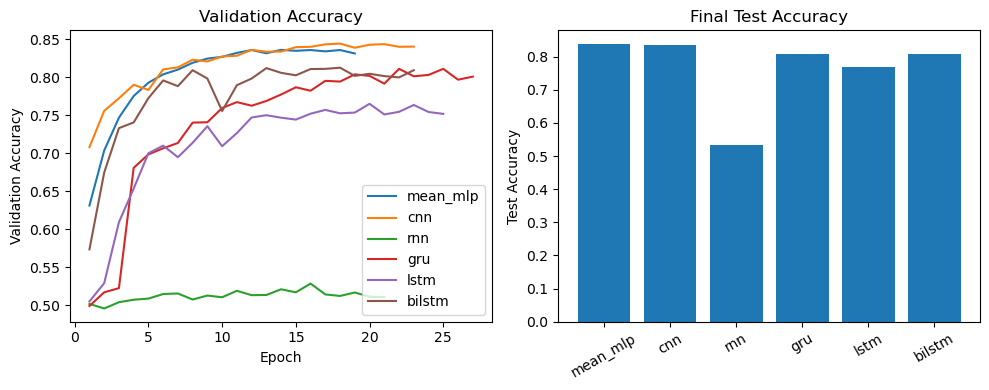

Model          Best Val Acc   Test Acc
----------------------------------------
mean_mlp             0.8363     0.8375
cnn                  0.8445     0.8345
rnn                  0.5288     0.5333
gru                  0.8113     0.8077
lstm                 0.7652     0.7675
bilstm               0.8127     0.8093


In [15]:
# Compare validation curves and final test accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for model_name, result in results.items():
    history = result["history"]
    epochs = range(1, len(history["val_accuracy"]) + 1)
    plt.plot(epochs, history["val_accuracy"], label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
model_names = list(results.keys())
test_accuracies = [results[name]["test_accuracy"] for name in model_names]
plt.bar(model_names, test_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(f"{'Model':<12} {'Best Val Acc':>14} {'Test Acc':>10}")
print("-" * 40)
for model_name, result in results.items():
    print(f"{model_name:<12} {result['best_val_accuracy']:>14.4f} {result['test_accuracy']:>10.4f}")


## Error Analysis

Accuracy is useful, but examples are more memorable. The cell below prints a few reviews that the best model misclassified. This is often where sentiment analysis becomes interesting: sarcasm, mixed reviews, negation, long context, and ambiguous language can all fool sequence models.


In [16]:
# Inspect mistakes from the best model
best_model_name = max(results, key=lambda name: results[name]["test_accuracy"])
best_result = results[best_model_name]
predictions = best_result["test_predictions"]
labels = best_result["test_labels"]

mistake_indices = (predictions != labels).nonzero(as_tuple=True)[0]
print(f"Best model: {best_model_name}")
print(f"Number of test mistakes: {len(mistake_indices)}")

for display_index in mistake_indices[:5]:
    subset_index = test_dataset.indices[int(display_index)]
    original_index = eval_subset.indices[subset_index]
    review_text, true_label = test_raw[original_index]
    predicted_label = int(predictions[int(display_index)])

    print("=" * 80)
    print(f"True label: {true_label} | Predicted label: {predicted_label}")
    print(clean_text(review_text)[:900], "...")


Best model: mean_mlp
Number of test mistakes: 650
True label: 1 | Predicted label: 0
And a hard spot somewhere else. I haven't seen this movie since i was quite young, maybe 12 or 13, who knows. But what i do know is this is the movie that taught me how to masturbate. I kid you not. I have no idea if it is any good by any real standards of today, but for me, back then, it was everything.  The only reason i feel comfortable writing this is because i'm sure no one will ever get around to reading it. I mean, really, who is going to look up this movie these days?  I just discovered that i have not yet used up the ten line minimum for the amount of length i most take up in a review. i had no idea there was such a minimum length, but there i go, like a student trying to fill up a page in a journal, my ten lines. thank you very much. ...
True label: 1 | Predicted label: 0
This film reappeared on channel 13 in the 1990s when they did a series of comedies from Hollywood in the 1930s and 1940s. 

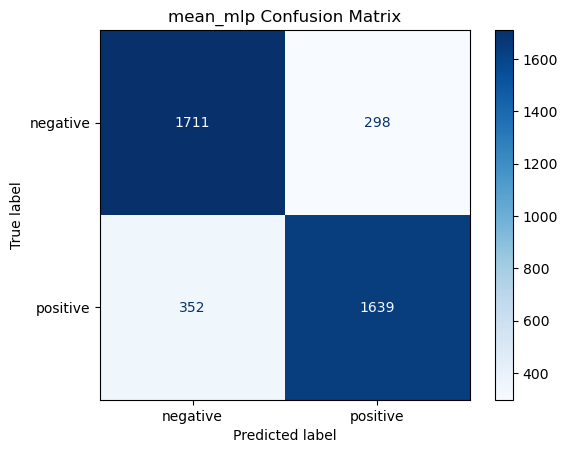

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84      2009
    positive       0.85      0.82      0.83      1991

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



In [17]:
# Confusion matrix for the best model
ConfusionMatrixDisplay.from_predictions(
    labels.numpy(),
    predictions.numpy(),
    display_labels=["negative", "positive"],
    cmap="Blues",
)
plt.title(f"{best_model_name} Confusion Matrix")
plt.show()

print(classification_report(
    labels.numpy(),
    predictions.numpy(),
    target_names=["negative", "positive"],
))


## Why Simple RNNs Struggle

A vanilla RNN repeatedly applies the same kind of update:

$$h_t = 	\tanh(W_x x_t + W_h h_{t-1} + b)$$

During backpropagation through time, gradients must pass through many repeated multiplications. They can shrink toward zero or grow too large. This is one reason simple RNNs often struggle with long-range dependencies.

GRUs and LSTMs add gates. Gates let the model learn when to keep, erase, or update information. This makes it easier to preserve useful context across many timesteps.


## Transformers for Sequence Modeling

RNNs process tokens one step at a time. Transformers process a sequence with attention. Attention lets each token build a representation by looking at other tokens in the same sequence.

For a sequence of token embeddings, a transformer creates three learned projections:

$$Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V$$

The attention weights are computed from query-key similarity:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Query**: what this token is looking for
- **Key**: what each token offers for matching
- **Value**: the information each token contributes

Vaswani et al. introduced the transformer architecture using multi-head self-attention, positional encoding, feed-forward blocks, residual connections, and layer normalization. Encoder-style models such as BERT are natural for classification. Decoder-style models such as GPT are natural for next-token generation.


In [18]:
# Scaled dot-product attention from scratch
import math


def scaled_dot_product_attention(query, key, value, attention_mask=None):
    key_dimension = query.size(-1)
    scores = query @ key.transpose(-2, -1)
    scores = scores / math.sqrt(key_dimension)

    if attention_mask is not None:
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))

    attention_weights = scores.softmax(dim=-1)
    attended_values = attention_weights @ value
    return attended_values, attention_weights


# Shape demo: batch size 2, sequence length 4, feature dimension 8
example_embeddings = torch.randn(2, 4, 8)
query_projection = nn.Linear(8, 8)
key_projection = nn.Linear(8, 8)
value_projection = nn.Linear(8, 8)

queries = query_projection(example_embeddings)
keys = key_projection(example_embeddings)
values = value_projection(example_embeddings)

attended_values, attention_weights = scaled_dot_product_attention(queries, keys, values)
print(f"Attended values shape: {tuple(attended_values.shape)}")
print(f"Attention weights shape: {tuple(attention_weights.shape)}")


Attended values shape: (2, 4, 8)
Attention weights shape: (2, 4, 4)


## Transformer Encoder Classifier Trained on IMDB

The classifier below uses the same IMDB token IDs as the recurrent models. It adds positional embeddings, passes the sequence through a transformer encoder, pools the sequence representation, and predicts sentiment.

This is not BERT pretraining. It is a supervised transformer encoder trained directly for IMDB classification.


In [19]:
# Transformer encoder classifier using the notebook vocabulary
class TransformerTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        sequence_length,
        embed_dim=128,
        num_heads=4,
        hidden_dim=256,
        num_layers=2,
        pad_idx=0,
        dropout=0.2,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(sequence_length, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device).unsqueeze(0)
        positions = positions.expand(batch_size, sequence_length)

        token_embeddings = self.token_embedding(token_ids)
        position_embeddings = self.position_embedding(positions)
        embeddings = token_embeddings + position_embeddings

        padding_mask = token_ids == self.pad_idx
        encoded_tokens = self.encoder(
            embeddings,
            src_key_padding_mask=padding_mask,
        )

        non_padding_mask = (token_ids != self.pad_idx).unsqueeze(-1)
        pooled = (encoded_tokens * non_padding_mask).sum(dim=1)
        pooled = pooled / non_padding_mask.sum(dim=1).clamp(min=1)
        return self.classifier(self.dropout(pooled)).squeeze(1)


transformer_classifier = TransformerTextClassifier(
    vocab_size=len(token_to_id),
    sequence_length=SEQUENCE_LENGTH,
    pad_idx=pad_idx,
)

transformer_result = train_text_classifier(
    transformer_classifier,
    "transformer_encoder",
    train_loader,
    val_loader,
    test_loader,
    max_epochs=20,
    patience=5,
    learning_rate=3e-4,
    weight_decay=1e-4,
    gradient_clip=1.0,
)
results["transformer_encoder"] = transformer_result


transformer_encoder | Epoch 001 | Train Loss: 0.6262 | Val Loss: 0.5523 | Val Acc: 0.7177 | No Improve: 0/5 | Time: 1.1s


/home/rwhite/.local/share/mamba/envs/xai-s26/lib/python3.11/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


transformer_encoder | Epoch 002 | Train Loss: 0.4842 | Val Loss: 0.5053 | Val Acc: 0.7578 | No Improve: 0/5 | Time: 1.1s
transformer_encoder | Epoch 003 | Train Loss: 0.4154 | Val Loss: 0.4749 | Val Acc: 0.7765 | No Improve: 0/5 | Time: 1.1s
transformer_encoder | Epoch 004 | Train Loss: 0.3621 | Val Loss: 0.4660 | Val Acc: 0.7913 | No Improve: 0/5 | Time: 1.1s
transformer_encoder | Epoch 005 | Train Loss: 0.3112 | Val Loss: 0.5394 | Val Acc: 0.7708 | No Improve: 1/5 | Time: 1.0s
transformer_encoder | Epoch 006 | Train Loss: 0.2689 | Val Loss: 0.5583 | Val Acc: 0.7925 | No Improve: 0/5 | Time: 1.1s
transformer_encoder | Epoch 007 | Train Loss: 0.2271 | Val Loss: 0.5827 | Val Acc: 0.7855 | No Improve: 1/5 | Time: 1.1s
transformer_encoder | Epoch 008 | Train Loss: 0.1834 | Val Loss: 0.6240 | Val Acc: 0.7947 | No Improve: 0/5 | Time: 1.0s
transformer_encoder | Epoch 009 | Train Loss: 0.1450 | Val Loss: 0.7543 | Val Acc: 0.7800 | No Improve: 1/5 | Time: 1.1s
transformer_encoder | Epoch 010 

## Masked Language Modeling Tutorial

BERT-style pretraining uses masked language modeling. Some input tokens are replaced with a special mask token, and the model predicts the original tokens at those positions.

Example:

```text
this movie was great -> this [MASK] was great
```

The model is trained to recover `movie`. This teaches bidirectional context because the prediction can use words on both sides of the mask.


In [20]:
# Build masked-language-modeling batches from IMDB token IDs
MASK_TOKEN = "<MASK>"
mask_token_id = len(token_to_id)
mlm_vocab_size = len(token_to_id) + 1


def make_mlm_batch(token_ids, mask_probability=0.15):
    inputs = token_ids.clone()
    labels = torch.full_like(token_ids, fill_value=-100)

    can_mask = token_ids != pad_idx
    random_values = torch.rand(token_ids.shape)
    mask_positions = (random_values < mask_probability) & can_mask.cpu()

    labels[mask_positions] = token_ids[mask_positions]
    inputs[mask_positions] = mask_token_id
    return inputs, labels


class TransformerMaskedLanguageModel(nn.Module):
    def __init__(self, vocab_size, sequence_length, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(sequence_length, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device).unsqueeze(0).expand(batch_size, sequence_length)
        embeddings = self.token_embedding(token_ids) + self.position_embedding(positions)
        padding_mask = token_ids == self.pad_idx
        encoded = self.encoder(embeddings, src_key_padding_mask=padding_mask)
        return self.output_layer(encoded)


mlm_model = TransformerMaskedLanguageModel(
    vocab_size=mlm_vocab_size,
    sequence_length=SEQUENCE_LENGTH,
    pad_idx=pad_idx,
).to(device)
mlm_optimizer = torch.optim.AdamW(mlm_model.parameters(), lr=3e-4, weight_decay=1e-4)
mlm_loss_function = nn.CrossEntropyLoss(ignore_index=-100)

MLM_EPOCHS = 20
for epoch in range(MLM_EPOCHS):
    mlm_model.train()
    total_loss = 0.0
    total_seen = 0

    for token_ids, labels in train_loader:
        masked_inputs, mlm_labels = make_mlm_batch(token_ids)
        masked_inputs = masked_inputs.to(device, non_blocking=True)
        mlm_labels = mlm_labels.to(device, non_blocking=True)

        token_logits = mlm_model(masked_inputs)
        loss = mlm_loss_function(
            token_logits.reshape(-1, mlm_vocab_size),
            mlm_labels.reshape(-1),
        )

        mlm_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), max_norm=1.0)
        mlm_optimizer.step()

        total_loss += loss.item() * masked_inputs.size(0)
        total_seen += masked_inputs.size(0)

    print(f"MLM epoch {epoch + 1:03d} | Loss: {total_loss / total_seen:.4f}")


MLM epoch 001 | Loss: 7.0019
MLM epoch 002 | Loss: 6.4588
MLM epoch 003 | Loss: 6.4447
MLM epoch 004 | Loss: 6.4355
MLM epoch 005 | Loss: 6.4235
MLM epoch 006 | Loss: 6.4165
MLM epoch 007 | Loss: 6.4121
MLM epoch 008 | Loss: 6.3948
MLM epoch 009 | Loss: 6.3961
MLM epoch 010 | Loss: 6.3913
MLM epoch 011 | Loss: 6.3909
MLM epoch 012 | Loss: 6.3793
MLM epoch 013 | Loss: 6.3686
MLM epoch 014 | Loss: 6.3730
MLM epoch 015 | Loss: 6.3589
MLM epoch 016 | Loss: 6.3504
MLM epoch 017 | Loss: 6.3447
MLM epoch 018 | Loss: 6.3330
MLM epoch 019 | Loss: 6.3369
MLM epoch 020 | Loss: 6.3129


## Fine-Tuning the MLM Encoder on IMDB

After MLM pretraining, the encoder has learned token representations from unlabeled text. To fine-tune it for sentiment classification, attach a classification head and train with sentiment labels.


In [21]:
# Fine-tune the MLM encoder for IMDB sentiment classification
class MLMEncoderClassifier(nn.Module):
    def __init__(self, mlm_model, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_embedding = mlm_model.token_embedding
        self.position_embedding = mlm_model.position_embedding
        self.encoder = mlm_model.encoder
        embed_dim = mlm_model.output_layer.in_features
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device).unsqueeze(0).expand(batch_size, sequence_length)
        embeddings = self.token_embedding(token_ids) + self.position_embedding(positions)
        padding_mask = token_ids == self.pad_idx
        encoded = self.encoder(embeddings, src_key_padding_mask=padding_mask)
        non_padding_mask = (token_ids != self.pad_idx).unsqueeze(-1)
        pooled = (encoded * non_padding_mask).sum(dim=1) / non_padding_mask.sum(dim=1).clamp(min=1)
        return self.classifier(pooled).squeeze(1)


mlm_finetuned_classifier = MLMEncoderClassifier(mlm_model, pad_idx=pad_idx)
mlm_finetuned_result = train_text_classifier(
    mlm_finetuned_classifier,
    "mlm_encoder_finetuned",
    train_loader,
    val_loader,
    test_loader,
    max_epochs=100,
    patience=5,
    learning_rate=2e-4,
    weight_decay=1e-4,
    gradient_clip=1.0,
)
results["mlm_encoder_finetuned"] = mlm_finetuned_result


mlm_encoder_finetuned | Epoch 001 | Train Loss: 0.5667 | Val Loss: 0.5261 | Val Acc: 0.7338 | No Improve: 0/5 | Time: 1.1s
mlm_encoder_finetuned | Epoch 002 | Train Loss: 0.4731 | Val Loss: 0.4876 | Val Acc: 0.7592 | No Improve: 0/5 | Time: 1.1s
mlm_encoder_finetuned | Epoch 003 | Train Loss: 0.4261 | Val Loss: 0.4862 | Val Acc: 0.7695 | No Improve: 0/5 | Time: 1.0s
mlm_encoder_finetuned | Epoch 004 | Train Loss: 0.3871 | Val Loss: 0.4822 | Val Acc: 0.7708 | No Improve: 0/5 | Time: 1.1s
mlm_encoder_finetuned | Epoch 005 | Train Loss: 0.3531 | Val Loss: 0.4877 | Val Acc: 0.7688 | No Improve: 1/5 | Time: 1.0s
mlm_encoder_finetuned | Epoch 006 | Train Loss: 0.3123 | Val Loss: 0.5656 | Val Acc: 0.7552 | No Improve: 2/5 | Time: 1.1s
mlm_encoder_finetuned | Epoch 007 | Train Loss: 0.2742 | Val Loss: 0.5587 | Val Acc: 0.7682 | No Improve: 3/5 | Time: 1.1s
mlm_encoder_finetuned | Epoch 008 | Train Loss: 0.2311 | Val Loss: 0.6085 | Val Acc: 0.7635 | No Improve: 4/5 | Time: 1.0s
mlm_encoder_fine

## GPT-Style Causal Language Modeling Tutorial

GPT-style pretraining predicts the next token from previous tokens. The model uses a causal mask so position $t$ cannot attend to future positions.

```text
input:  this movie was
label:       movie was great
```

This objective trains a left-to-right language model. For classification, a GPT-style model can use the final non-padding token representation as the sequence summary.


In [22]:
# GPT-style decoder-only transformer for causal language modeling
class CausalTransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size, sequence_length, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.sequence_length = sequence_length
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.position_embedding = nn.Embedding(sequence_length, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True,
            activation="gelu",
        )
        self.decoder_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(embed_dim, vocab_size)

    def forward(self, token_ids):
        batch_size, sequence_length = token_ids.shape
        positions = torch.arange(sequence_length, device=token_ids.device).unsqueeze(0).expand(batch_size, sequence_length)
        embeddings = self.token_embedding(token_ids) + self.position_embedding(positions)
        causal_mask = torch.triu(
            torch.ones(sequence_length, sequence_length, device=token_ids.device),
            diagonal=1,
        ).bool()
        padding_mask = token_ids == self.pad_idx
        hidden_states = self.decoder_blocks(
            embeddings,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )
        return self.output_layer(hidden_states), hidden_states


gpt_vocab_size = len(token_to_id)
gpt_model = CausalTransformerLanguageModel(
    vocab_size=gpt_vocab_size,
    sequence_length=SEQUENCE_LENGTH,
    pad_idx=pad_idx,
).to(device)
gpt_optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=3e-4, weight_decay=1e-4)
gpt_loss_function = nn.CrossEntropyLoss(ignore_index=pad_idx)

GPT_PRETRAIN_EPOCHS = 20
for epoch in range(GPT_PRETRAIN_EPOCHS):
    gpt_model.train()
    total_loss = 0.0
    total_seen = 0

    for token_ids, labels in train_loader:
        input_ids = token_ids[:, :-1].to(device, non_blocking=True)
        target_ids = token_ids[:, 1:].to(device, non_blocking=True)

        token_logits, hidden_states = gpt_model(input_ids)
        loss = gpt_loss_function(
            token_logits.reshape(-1, gpt_vocab_size),
            target_ids.reshape(-1),
        )

        gpt_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), max_norm=1.0)
        gpt_optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        total_seen += input_ids.size(0)

    print(f"GPT-style LM epoch {epoch + 1:03d} | Loss: {total_loss / total_seen:.4f}")


GPT-style LM epoch 001 | Loss: 6.9515
GPT-style LM epoch 002 | Loss: 6.2234
GPT-style LM epoch 003 | Loss: 5.9732
GPT-style LM epoch 004 | Loss: 5.8295
GPT-style LM epoch 005 | Loss: 5.7336
GPT-style LM epoch 006 | Loss: 5.6603
GPT-style LM epoch 007 | Loss: 5.6001
GPT-style LM epoch 008 | Loss: 5.5474
GPT-style LM epoch 009 | Loss: 5.5001
GPT-style LM epoch 010 | Loss: 5.4573
GPT-style LM epoch 011 | Loss: 5.4177
GPT-style LM epoch 012 | Loss: 5.3810
GPT-style LM epoch 013 | Loss: 5.3472
GPT-style LM epoch 014 | Loss: 5.3152
GPT-style LM epoch 015 | Loss: 5.2857
GPT-style LM epoch 016 | Loss: 5.2575
GPT-style LM epoch 017 | Loss: 5.2307
GPT-style LM epoch 018 | Loss: 5.2053
GPT-style LM epoch 019 | Loss: 5.1807
GPT-style LM epoch 020 | Loss: 5.1579


In [23]:
# Fine-tune the GPT-style model on IMDB sentiment
class CausalTransformerClassifier(nn.Module):
    def __init__(self, language_model, pad_idx=0):
        super().__init__()
        self.language_model = language_model
        self.pad_idx = pad_idx
        embed_dim = language_model.output_layer.in_features
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, token_ids):
        token_logits, hidden_states = self.language_model(token_ids)
        non_padding_lengths = (token_ids != self.pad_idx).sum(dim=1).clamp(min=1)
        final_indices = non_padding_lengths - 1
        batch_indices = torch.arange(token_ids.size(0), device=token_ids.device)
        final_hidden = hidden_states[batch_indices, final_indices]
        return self.classifier(final_hidden).squeeze(1)


gpt_finetuned_classifier = CausalTransformerClassifier(gpt_model, pad_idx=pad_idx)
gpt_finetuned_result = train_text_classifier(
    gpt_finetuned_classifier,
    "gpt_style_finetuned",
    train_loader,
    val_loader,
    test_loader,
    max_epochs=100,
    patience=5,
    learning_rate=2e-4,
    weight_decay=1e-4,
    gradient_clip=1.0,
)
results["gpt_style_finetuned"] = gpt_finetuned_result


gpt_style_finetuned | Epoch 001 | Train Loss: 0.6746 | Val Loss: 0.6096 | Val Acc: 0.6735 | No Improve: 0/5 | Time: 1.3s
gpt_style_finetuned | Epoch 002 | Train Loss: 0.5519 | Val Loss: 0.5600 | Val Acc: 0.7107 | No Improve: 0/5 | Time: 1.3s
gpt_style_finetuned | Epoch 003 | Train Loss: 0.4787 | Val Loss: 0.5349 | Val Acc: 0.7358 | No Improve: 0/5 | Time: 1.2s
gpt_style_finetuned | Epoch 004 | Train Loss: 0.4160 | Val Loss: 0.5434 | Val Acc: 0.7418 | No Improve: 0/5 | Time: 1.2s
gpt_style_finetuned | Epoch 005 | Train Loss: 0.3615 | Val Loss: 0.5395 | Val Acc: 0.7532 | No Improve: 0/5 | Time: 1.2s
gpt_style_finetuned | Epoch 006 | Train Loss: 0.3074 | Val Loss: 0.5717 | Val Acc: 0.7575 | No Improve: 0/5 | Time: 1.2s
gpt_style_finetuned | Epoch 007 | Train Loss: 0.2585 | Val Loss: 0.6220 | Val Acc: 0.7562 | No Improve: 1/5 | Time: 1.2s
gpt_style_finetuned | Epoch 008 | Train Loss: 0.2157 | Val Loss: 0.6825 | Val Acc: 0.7468 | No Improve: 2/5 | Time: 1.2s
gpt_style_finetuned | Epoch 009 

## Off-the-Shelf Pretrained Transformers

The earlier transformer models were trained inside this notebook. Modern practice often starts from pretrained models.

- **BERT-style** models are encoder-only and are commonly fine-tuned for classification.
- **GPT-style** models are decoder-only and can also be fine-tuned for classification by adding a classification head.

The cells below use Hugging Face `transformers`. This package is required for the pretrained-model section.


In [24]:
# Hugging Face tools for pretrained transformer fine-tuning
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification


In [25]:
# Dataset wrapper that tokenizes raw IMDB text with a pretrained tokenizer
class HuggingFaceIMDBDataset(Dataset):
    def __init__(self, samples, tokenizer, max_length=256):
        self.samples = samples
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        text, label = self.samples[index]
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


def balanced_sample(samples, sample_size, seed=0):
    negative_samples = [sample for sample in samples if sample[1] == 0]
    positive_samples = [sample for sample in samples if sample[1] == 1]

    generator = torch.Generator().manual_seed(seed)
    per_class = sample_size // 2
    negative_indices = torch.randperm(len(negative_samples), generator=generator)[:per_class]
    positive_indices = torch.randperm(len(positive_samples), generator=generator)[:per_class]

    sampled = [negative_samples[index] for index in negative_indices.tolist()]
    sampled += [positive_samples[index] for index in positive_indices.tolist()]

    permutation = torch.randperm(len(sampled), generator=generator)
    return [sampled[index] for index in permutation.tolist()]


def make_hf_loaders(tokenizer, train_size=2000, eval_size=1000, batch_size=8, max_length=256):
    train_samples = balanced_sample(train_raw, train_size, seed=SEED)
    eval_samples = balanced_sample(test_raw, eval_size, seed=SEED + 1)

    split = eval_size // 2
    val_samples = eval_samples[:split]
    test_samples = eval_samples[split:]

    print("HF train labels:", Counter(label for text, label in train_samples))
    print("HF val labels:", Counter(label for text, label in val_samples))
    print("HF test labels:", Counter(label for text, label in test_samples))

    train_dataset = HuggingFaceIMDBDataset(train_samples, tokenizer, max_length=max_length)
    val_dataset = HuggingFaceIMDBDataset(val_samples, tokenizer, max_length=max_length)
    test_dataset = HuggingFaceIMDBDataset(test_samples, tokenizer, max_length=max_length)

    train_loader_hf = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    val_loader_hf = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    test_loader_hf = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    return train_loader_hf, val_loader_hf, test_loader_hf


In [26]:
# Fine-tune a pretrained transformer sequence classifier
def fine_tune_pretrained_sequence_classifier(
    model_name,
    run_name,
    *,
    max_epochs=2,
    patience=2,
    learning_rate=2e-5,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_loader_hf, val_loader_hf, test_loader_hf = make_hf_loaders(tokenizer)

    label2id = {"negative": 0, "positive": 1}
    id2label = {0: "negative", 1: "positive"}
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=2,
        label2id=label2id,
        id2label=id2label,
        pad_token_id=tokenizer.pad_token_id,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
    best_val_accuracy = 0.0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0.0
        seen = 0

        for batch in train_loader_hf:
            batch = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * batch["labels"].size(0)
            seen += batch["labels"].size(0)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader_hf:
                batch = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
                logits = model(**batch).logits
                predictions = logits.argmax(dim=1)
                correct += (predictions == batch["labels"]).sum().item()
                total += batch["labels"].size(0)

        val_accuracy = correct / total
        print(
            f"{run_name:<16} | Epoch {epoch + 1:03d} | "
            f"Train Loss: {total_loss / seen:.4f} | Val Acc: {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping {run_name} at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader_hf:
            batch = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
            logits = model(**batch).logits
            all_predictions.append(logits.argmax(dim=1).cpu())
            all_labels.append(batch["labels"].cpu())

    predictions = torch.cat(all_predictions)
    labels = torch.cat(all_labels)
    test_accuracy = (predictions == labels).float().mean().item()
    print(f"{run_name} test accuracy: {test_accuracy:.4f}")

    return {
        "model": model,
        "tokenizer": tokenizer,
        "best_val_accuracy": best_val_accuracy,
        "test_accuracy": test_accuracy,
        "test_predictions": predictions,
        "test_labels": labels,
    }


In [28]:
# Fine-tune off-the-shelf BERT- and GPT-style models on IMDB
bert_finetuned_result = fine_tune_pretrained_sequence_classifier(
    "distilbert-base-uncased",
    "distilbert_imdb",
    max_epochs=100,
    patience=5,
    learning_rate=2e-5,
)

gpt_finetuned_result = fine_tune_pretrained_sequence_classifier(
    "distilgpt2",
    "distilgpt2_imdb",
    max_epochs=100,
    patience=5,
    learning_rate=2e-5,
)


HF train labels: Counter({1: 1000, 0: 1000})
HF val labels: Counter({1: 256, 0: 244})
HF test labels: Counter({0: 256, 1: 244})


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilbert_imdb  | Epoch 001 | Train Loss: 0.4485 | Val Acc: 0.8720
distilbert_imdb  | Epoch 002 | Train Loss: 0.2673 | Val Acc: 0.8800
distilbert_imdb  | Epoch 003 | Train Loss: 0.1448 | Val Acc: 0.8840
distilbert_imdb  | Epoch 004 | Train Loss: 0.0905 | Val Acc: 0.8780
distilbert_imdb  | Epoch 005 | Train Loss: 0.0333 | Val Acc: 0.8720
distilbert_imdb  | Epoch 006 | Train Loss: 0.0338 | Val Acc: 0.8880
distilbert_imdb  | Epoch 007 | Train Loss: 0.0108 | Val Acc: 0.8700
distilbert_imdb  | Epoch 008 | Train Loss: 0.0499 | Val Acc: 0.8740
distilbert_imdb  | Epoch 009 | Train Loss: 0.0277 | Val Acc: 0.8740
distilbert_imdb  | Epoch 010 | Train Loss: 0.0061 | Val Acc: 0.8720
distilbert_imdb  | Epoch 011 | Train Loss: 0.0164 | Val Acc: 0.8800
Early stopping distilbert_imdb at epoch 11
distilbert_imdb test accuracy: 0.8720


You passed `num_labels=2` which is incompatible to the `id2label` map of length `1`.


HF train labels: Counter({1: 1000, 0: 1000})
HF val labels: Counter({1: 256, 0: 244})
HF test labels: Counter({0: 256, 1: 244})


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


distilgpt2_imdb  | Epoch 001 | Train Loss: 0.5801 | Val Acc: 0.8280
distilgpt2_imdb  | Epoch 002 | Train Loss: 0.3501 | Val Acc: 0.8340
distilgpt2_imdb  | Epoch 003 | Train Loss: 0.2795 | Val Acc: 0.8540
distilgpt2_imdb  | Epoch 004 | Train Loss: 0.2367 | Val Acc: 0.8440
distilgpt2_imdb  | Epoch 005 | Train Loss: 0.1736 | Val Acc: 0.8620
distilgpt2_imdb  | Epoch 006 | Train Loss: 0.1111 | Val Acc: 0.8640
distilgpt2_imdb  | Epoch 007 | Train Loss: 0.0816 | Val Acc: 0.8660
distilgpt2_imdb  | Epoch 008 | Train Loss: 0.0389 | Val Acc: 0.8620
distilgpt2_imdb  | Epoch 009 | Train Loss: 0.0356 | Val Acc: 0.8460
distilgpt2_imdb  | Epoch 010 | Train Loss: 0.0327 | Val Acc: 0.8580
distilgpt2_imdb  | Epoch 011 | Train Loss: 0.0163 | Val Acc: 0.8780
distilgpt2_imdb  | Epoch 012 | Train Loss: 0.0352 | Val Acc: 0.8540
distilgpt2_imdb  | Epoch 013 | Train Loss: 0.0298 | Val Acc: 0.8560
distilgpt2_imdb  | Epoch 014 | Train Loss: 0.0397 | Val Acc: 0.8620
distilgpt2_imdb  | Epoch 015 | Train Loss: 0.006

## Takeaways

Sequence models process ordered data. A recurrent model maintains a hidden state that changes as it reads the sequence.

Mean-pooled embeddings are fast and useful, but they mostly ignore order. CNNs capture local word patterns. Simple RNNs introduce sequential memory, while GRUs and LSTMs improve memory with gates. Bidirectional LSTMs use both left and right context when the whole sequence is available.

Transformers use attention instead of recurrence. Query-key-value attention lets each token decide which other tokens matter. Encoder-style transformers such as BERT are natural for classification and masked language modeling. Decoder-style transformers such as GPT are natural for causal language modeling and generation.

For IMDB sentiment classification, model quality depends on architecture, data size, sequence length, vocabulary, optimization, and pretraining. The important habit is to compare models under the same data split and training procedure.
